<a href="https://colab.research.google.com/github/novakai-one/claude-ai-demo/blob/main/notebooks/fields/02_classic_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Field 2 · Classic machine learning · taste project*

# Which kind of model fits this data best, and how do I know it's not fooling me?

> **In short**
>
> **Which kind of model fits this data best, and how do I know it's not fooling me?**
>
> Try several kinds of model, and judge each one only on data it never saw while learning. Cross-validation does that fairly, several times over, so one lucky split can't fool you.

## Where you'll end up

By the end you will have built, from scratch and then with scikit-learn:

1. **A straight-line fit** by least squares.
2. **k-nearest neighbours**, **a decision tree** and **k-means clustering**.
3. **Pictures of each model's boundaries** (below), and **cross-validation** to pick a winner honestly.

Running every cell takes under a minute.

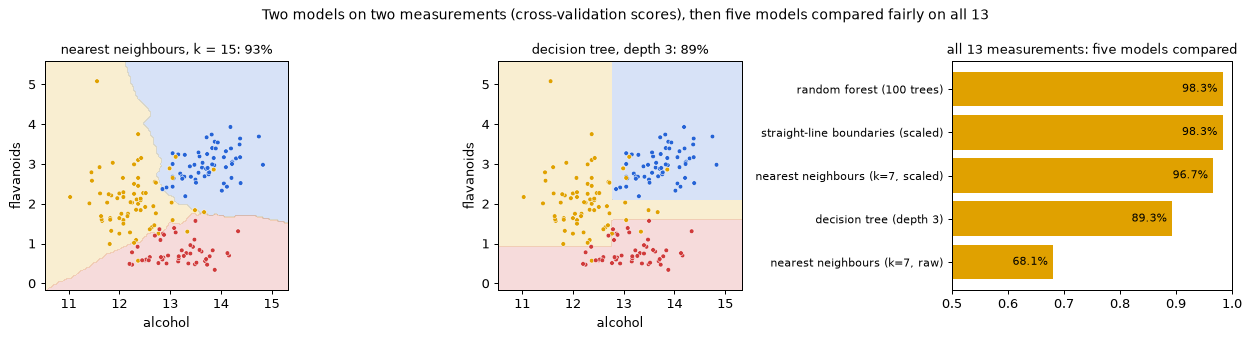

## How to use this notebook

- Run each grey code cell with **Shift + Enter**, top to bottom.
- 🤔 **Predict first** boxes ask you to guess before you run. The answer is one click away.
- 🐍 **Python notes** explain Python as it comes up. This notebook introduces **pandas**, the standard table library.
- Exercise solutions are in collapsed cells. In Colab, double-click a solution's title to open it.

## 1. The problem: tell three wines apart

178 wines from three growers (call them A, B and C) were measured chemically: 13 numbers each.
A new bottle arrives without a label. **Which grower made it?**

This is the classic situation: a table of measurements, a known answer for past rows, a new row to label.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
df = wine.frame
df["kind"] = df["target"].map(dict(enumerate(["A", "B", "C"])))
FEATURES = ["alcohol", "flavanoids"]
X = df[FEATURES].to_numpy()
y = df["target"].to_numpy()
COLOURS = np.array(["#2563d6", "#e0a100", "#d03a3a"])

print(df.shape)
df.head()

(178, 15)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,kind
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,A
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,A
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,A
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,A
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,A


🐍 **Python notes: pandas**
- A **DataFrame** (`df`) is a table with named columns. `df.head()` shows the first rows; `df.shape` is (rows, columns).
- `df["alcohol"]` is one column. `df[["alcohol", "flavanoids"]]` is a smaller table.
- `.map(...)` replaces each value using a dict; `.to_numpy()` turns a table into a numpy array.
- `dict(enumerate(["A", "B", "C"]))` makes `{0: "A", 1: "B", 2: "C"}`: `enumerate` numbers the items of a list.

     alcohol       flavanoids       color_intensity      
        mean   std       mean   std            mean   std
kind                                                     
A      13.74  0.46       2.98  0.40            5.53  1.24
B      12.28  0.54       2.08  0.71            3.09  0.92
C      13.15  0.53       0.78  0.29            7.40  2.31


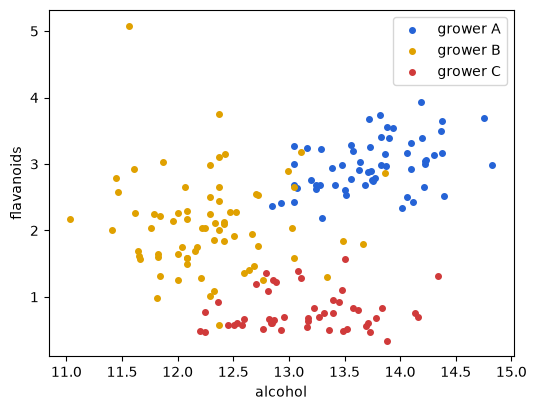

In [2]:
print(df.groupby("kind")[["alcohol", "flavanoids", "color_intensity"]].agg(["mean", "std"]).round(2))
fig, ax = plt.subplots(figsize=(6, 4.5))
for k, name in enumerate("ABC"):
    m = y == k
    ax.scatter(X[m, 0], X[m, 1], c=COLOURS[k], s=16, label=f"grower {name}")
ax.set_xlabel("alcohol"); ax.set_ylabel("flavanoids"); ax.legend(); plt.show()

🐍 **Python notes**
- `df.groupby("kind")[...].agg(["mean", "std"])` splits the table by grower and computes each column's mean (average) and standard deviation (typical distance from the average) per group.
- `m = y == k` makes a list of True/False, one per bottle. `X[m, 0]` keeps the rows where it is True, column 0: a **boolean mask**.
- `f"grower {name}"` is an f-string: the value of `name` is put inside the text.

**What you see:** with only two of the 13 measurements, the three growers already sit in different areas, with some overlap. To keep every picture flat, the models below use these two.

## 2. Predicting a number: the best straight line

First a simpler question: **predict flavanoids from total phenols** (another measurement). The answer is a number, not a label.

Draw a line $\hat{y} = a\,x + b$, where $\hat{y}$ (say "y-hat") is the line's prediction. For each wine, the error is the gap between the line and the real value. Choose $a$ and $b$ to make the **sum of squared gaps** as small as possible.

by hand:      flavanoids = 1.380 x phenols -1.138


scikit-learn: flavanoids = 1.380 x phenols -1.138


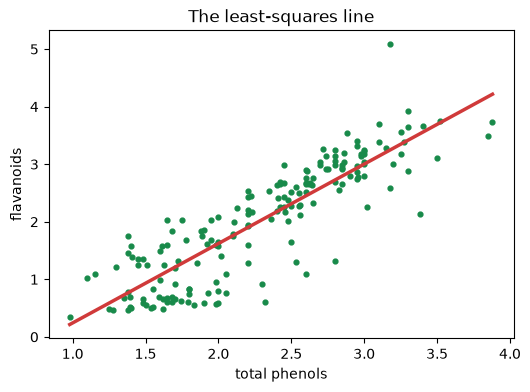

In [3]:
x1 = df["total_phenols"].to_numpy()
y1 = df["flavanoids"].to_numpy()

# least squares by hand: put a column of 1s next to x, then solve A^T A [a, b] = A^T y
A = np.c_[x1, np.ones_like(x1)]
a, b = np.linalg.solve(A.T @ A, A.T @ y1)
print(f"by hand:      flavanoids = {a:.3f} x phenols {b:+.3f}")

from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(x1[:, None], y1)
print(f"scikit-learn: flavanoids = {lr.coef_[0]:.3f} x phenols {lr.intercept_:+.3f}")

plt.figure(figsize=(6, 4))
plt.scatter(x1, y1, s=12, color="#188a4a")
xs = np.linspace(x1.min(), x1.max(), 2)
plt.plot(xs, a * xs + b, color="#d03a3a", lw=2.5)
plt.xlabel("total phenols"); plt.ylabel("flavanoids"); plt.title("The least-squares line"); plt.show()

🐍 **Python notes**
- `np.c_[a, b]` sticks columns side by side. `x1[:, None]` turns a list of numbers into a one-column table, which scikit-learn expects.
- `A.T` is the table turned on its side (rows become columns: the **transpose**). `@` multiplies matrices.
- `{a:.3f}` prints a number with 3 decimals; `{b:+.3f}` also prints its sign.

**What it's called:** predicting a number is *regression*; predicting a label is *classification*. Minimising the sum of squared gaps is *least squares*. The formula you solved is the *normal equation*:

$$A^\top A \begin{bmatrix} a \\ b \end{bmatrix} = A^\top \color{green}{y}$$

It comes from finding where the squared-error total stops going down as you change $a$ or $b$: where its slope in both directions is zero. That is calculus and linear algebra together.

## 3. Label a bottle by the bottles nearest to it

Back to the growers. For a new bottle, find the $k$ past bottles closest to it, and take their most common grower.

First, a drawing helper used for every model below. It asks the model for a label at 22,500 points on a grid (150 × 150), and colours each area by the answer.

In [4]:
def boundary(ax, predict, title, X=X, y=y):
    gx, gy = np.meshgrid(np.linspace(X[:, 0].min() - .5, X[:, 0].max() + .5, 150),
                         np.linspace(X[:, 1].min() - .5, X[:, 1].max() + .5, 150))
    grid = np.c_[gx.ravel(), gy.ravel()]
    z = predict(grid).reshape(gx.shape)
    ax.contourf(gx, gy, z, levels=[-0.5, 0.5, 1.5, 2.5], colors=COLOURS, alpha=0.18)
    ax.scatter(X[:, 0], X[:, 1], c=COLOURS[y], s=14, edgecolor="white", linewidth=0.4)
    ax.set_xlabel(FEATURES[0]); ax.set_ylabel(FEATURES[1]); ax.set_title(title, fontsize=10)

🐍 `np.meshgrid` makes the grid's x and y values. `.ravel()` flattens a grid into one long list, and `.reshape(gx.shape)` turns the answers back into a grid. `predict` is a function passed in as an argument, so the same helper draws any model.

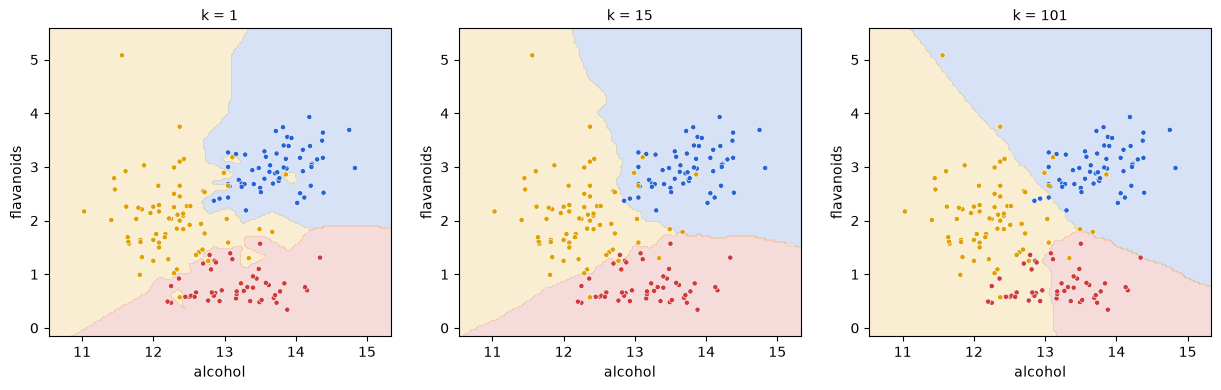

In [5]:
def knn_predict(X_train, y_train, X_new, k=5):
    out = []
    for p in X_new:
        d = np.sqrt(((X_train - p) ** 2).sum(axis=1))        # distance to every training bottle
        nearest = np.argsort(d)[:k]                          # sort, keep the k closest
        out.append(np.bincount(y_train[nearest], minlength=3).argmax())
    return np.array(out)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, k in zip(axes, [1, 15, 101]):
    boundary(ax, lambda g, k=k: knn_predict(X, y, g, k), f"k = {k}")
plt.show()

🐍 **Python notes**
- `np.bincount(labels, minlength=3)` counts how many 0s, 1s and 2s there are; `.argmax()` picks the most common.
- `zip(axes, [1, 15, 101])` pairs the three plots with the three values of `k`.
- `lambda g, k=k: knn_predict(X, y, g, k)` makes a one-line function of `g`. The `k=k` part stores this loop's `k` inside the function; without it, all three would use the last `k`.

**What you see:** with $k = 1$ the regions have small islands around single bottles. With $k = 101$, each vote uses more than half of all 178 bottles, so the smallest group (grower C) loses much of its area.

**What it's called:** this model is *k-nearest neighbours* (kNN). Its distance is the straight-line (*Euclidean*) distance:

$$d(\mathbf{p}, \mathbf{q}) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2}$$

Sorting every distance for every new point is slow for big data; libraries use trees (k-d trees) to find nearest neighbours fast.

### 🤔 Predict first

Score each $k$ on the **same bottles it learned from**. **Which $k$ scores highest?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

**$k = 1$, at 100%**: each bottle's nearest neighbour is itself. That score says nothing about new bottles. The next section fixes the test.

</details>

In [6]:
for k in [1, 15, 101]:
    acc = (knn_predict(X, y, X, k) == y).mean()
    print(f"k = {k:2d}: accuracy on its own training bottles {acc:.0%}")

k =  1: accuracy on its own training bottles 100%
k = 15: accuracy on its own training bottles 94%
k = 101: accuracy on its own training bottles 81%


## 4. An honest test

Hold some bottles back, train on the rest, and score only on the held-back ones.
One split can be lucky, so do it 5 times: split the bottles into 5 groups (**folds**), hold out each fold in turn, and average the 5 scores.

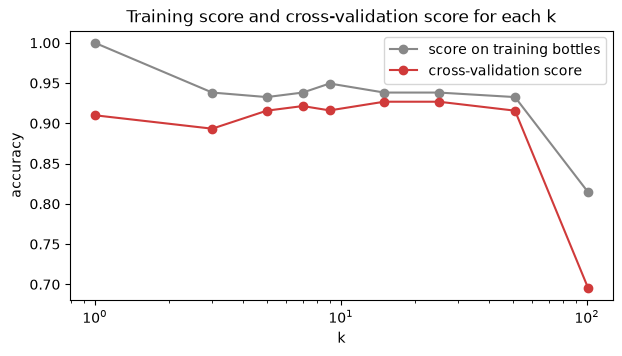

best k by cross-validation: 15 (92.7%)


In [7]:
def cross_validate(predict_fn, X, y, folds=5, seed=0):
    idx = np.random.default_rng(seed).permutation(len(X))
    scores = []
    for f in range(folds):
        test = idx[f::folds]                              # every 5th bottle, starting at f
        train = np.setdiff1d(idx, test)
        scores.append((predict_fn(X[train], y[train], X[test]) == y[test]).mean())
    return np.mean(scores)

ks = [1, 3, 5, 7, 9, 15, 25, 51, 101]
cv = [cross_validate(lambda a, b, c, k=k: knn_predict(a, b, c, k), X, y) for k in ks]
train = [(knn_predict(X, y, X, k) == y).mean() for k in ks]
plt.figure(figsize=(7, 3.5))
plt.plot(ks, train, "o-", label="score on training bottles", color="#888")
plt.plot(ks, cv, "o-", label="cross-validation score", color="#d03a3a")
plt.xscale("log"); plt.xlabel("k"); plt.ylabel("accuracy"); plt.legend(); plt.title("Training score and cross-validation score for each k"); plt.show()
best_k = ks[int(np.argmax(cv))]
print("best k by cross-validation:", best_k, f"({max(cv):.1%})")

🐍 `idx[f::folds]` takes every 5th item starting at position `f`. `np.setdiff1d(a, b)` keeps the items of `a` that are not in `b`.

**What you see:** the training score is 100% at $k = 1$ and lower for larger $k$. The cross-validation score stays between about 89% and 93% from $k = 1$ to $k = 51$, then drops sharply at $k = 101$.
**The training score can't tell you how a model does on new bottles; only held-out bottles can.**

**What it's called:**
- scoring much better on training data than on new data is *overfitting* ($k = 1$: 100% against about 91%)
- smoothing away real structure is *underfitting* ($k = 101$)
- repeated held-out testing is *cross-validation*; accuracy is one *evaluation metric* (others count different kinds of mistakes separately)

## 5. A model that asks yes/no questions

Another approach: split the bottles with one question, like "alcohol < 12.8?". Choose the question that makes each side as **pure** (one grower) as possible. Then split each side again.

In [8]:
def gini(labels):
    """How mixed a group is: 0 = all one grower; higher = more mixed."""
    if len(labels) == 0:
        return 0.0
    p = np.bincount(labels, minlength=3) / len(labels)
    return 1 - (p ** 2).sum()

def best_split(X, y):
    best = (None, None, gini(y))
    for f in range(X.shape[1]):
        for t in np.unique(X[:, f]):
            left = X[:, f] < t
            if left.all() or not left.any():
                continue
            g = (left.sum() * gini(y[left]) + (~left).sum() * gini(y[~left])) / len(y)
            if g < best[2]:
                best = (f, t, g)
    return best

def grow(X, y, depth):
    f, t, g = best_split(X, y)
    if depth == 0 or f is None:
        return {"leaf": int(np.bincount(y, minlength=3).argmax())}
    left = X[:, f] < t
    return {"feature": f, "threshold": t, "yes": grow(X[left], y[left], depth - 1), "no": grow(X[~left], y[~left], depth - 1)}

def tree_predict_one(node, p):
    while "leaf" not in node:
        node = node["yes"] if p[node["feature"]] < node["threshold"] else node["no"]
    return node["leaf"]

def show(node, indent="", label=""):
    if "leaf" in node:
        print(indent + label + "grower " + "ABC"[node["leaf"]])
        return
    print(indent + label + f"{FEATURES[node['feature']]} < {node['threshold']:.2f}?")
    pad = indent + " " * len(label) + "  "
    show(node["yes"], pad, "yes → ")
    show(node["no"], pad, "no  → ")

tree = grow(X, y, depth=2)
show(tree)

alcohol < 12.79?
  yes → flavanoids < 0.99?
          yes → grower C
          no  → grower B
  no  → flavanoids < 1.59?
          yes → grower C
          no  → grower A


🐍 The tree is stored as **nested dicts**: each question node holds two smaller trees under `"yes"` and `"no"`. `grow` builds it **recursively**.

**What it's called:** this is a *decision tree*: literally a tree data structure, with a question at each internal node and an answer at each leaf. The purity score is the *Gini impurity*, $1 - \sum_k p_k^2$.

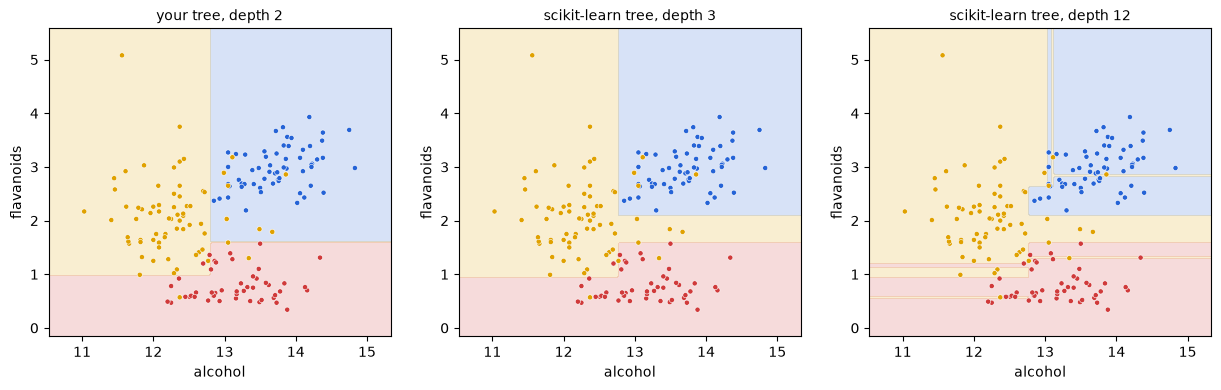

depth  1: cross-validation 56.1%
depth  2: cross-validation 87.6%
depth  3: cross-validation 88.8%
depth  5: cross-validation 88.8%
depth 12: cross-validation 89.9%


In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
mine = lambda g: np.array([tree_predict_one(tree, p) for p in g])
boundary(axes[0], mine, "your tree, depth 2")
for ax, depth in zip(axes[1:], [3, 12]):
    sk = DecisionTreeClassifier(max_depth=depth, random_state=0).fit(X, y)
    boundary(ax, sk.predict, f"scikit-learn tree, depth {depth}")
plt.show()

for depth in [1, 2, 3, 5, 12]:
    sk = DecisionTreeClassifier(max_depth=depth, random_state=0)
    print(f"depth {depth:2d}: cross-validation {cross_validate(lambda a, b, c: sk.fit(a, b).predict(c), X, y):.1%}")

**What you see:** a tree's boundaries are made of straight, axis-aligned steps. The depth-12 tree carves tiny boxes around single bottles, yet in cross-validation it scores about the same as depth 3. The extra boxes add complexity without helping much on new bottles. **When two models score about the same, prefer the simpler one.**

## 6. No labels at all: can the bottles still be grouped?

Suppose the growers' names were lost. **Can the bottles be grouped anyway?**

k-means: place 3 centres at random. Repeat: give each bottle to its nearest centre; move each centre to the average of its bottles.

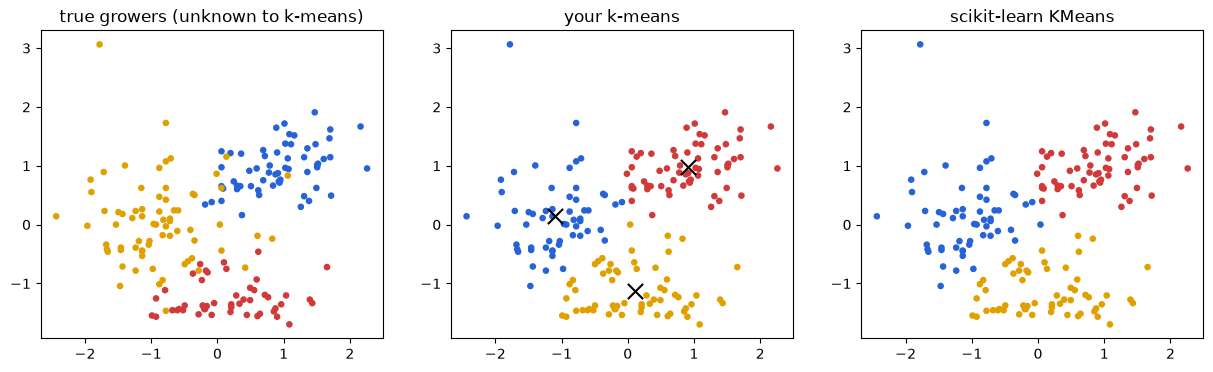

agreement with the true growers (1 = perfect, 0 = random): yours 0.72, scikit-learn 0.73


In [10]:
Z = (X - X.mean(axis=0)) / X.std(axis=0)                 # each column: average 0, spread 1

def kmeans(Z, k=3, steps=20, seed=0):
    r = np.random.default_rng(seed)
    centres = Z[r.choice(len(Z), k, replace=False)]
    for _ in range(steps):
        d = ((Z[:, None, :] - centres[None, :, :]) ** 2).sum(axis=2)
        group = d.argmin(axis=1)                          # nearest centre for each bottle
        centres = np.array([Z[group == j].mean(0) for j in range(k)])
    return group, centres

group, centres = kmeans(Z)
from sklearn.cluster import KMeans
sk_group = KMeans(3, n_init=10, random_state=0).fit_predict(Z)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(Z[:, 0], Z[:, 1], c=COLOURS[y], s=14); axes[0].set_title("true growers (unknown to k-means)")
axes[1].scatter(Z[:, 0], Z[:, 1], c=COLOURS[group], s=14); axes[1].scatter(*centres.T, marker="x", s=120, c="k"); axes[1].set_title("your k-means")
axes[2].scatter(Z[:, 0], Z[:, 1], c=COLOURS[sk_group], s=14); axes[2].set_title("scikit-learn KMeans")
plt.show()

from sklearn.metrics import adjusted_rand_score
print(f"agreement with the true growers (1 = perfect, 0 = random): yours {adjusted_rand_score(y, group):.2f}, "
      f"scikit-learn {adjusted_rand_score(y, sk_group):.2f}")

🐍 **Python notes**
- `(X - X.mean(axis=0)) / X.std(axis=0)` rescales each column to average 0 and spread 1, so a measurement with big numbers doesn't dominate the distances. scikit-learn's `StandardScaler` does the same.
- `Z[:, None, :] - centres[None, :, :]` gives every bottle-to-centre difference at once (178 × 3 × 2), by broadcasting.
- `axes[1].scatter(*centres.T, ...)`: `centres.T` has two rows (x values, y values), and `*` passes them as two arguments.

**What you see:** without ever seeing a label, k-means finds groups that mostly match the growers. The colours can be in a different order: k-means has no names for its groups.

**What it's called:** finding groups without labels is *clustering*, a kind of *unsupervised learning*. Everything before used labels: *supervised learning*.

## 7. Pick a winner, honestly

Now use all 13 measurements and let scikit-learn's cross-validation compare five models:

- nearest neighbours ($k = 7$), once on scaled measurements and once on raw ones
- a decision tree of depth 3
- straight-line boundaries between the groups (scikit-learn calls it `LogisticRegression`; despite the name, it predicts labels)
- a random forest: 100 decision trees, each trained on a random part of the data, voting together

### 🤔 Predict first

With all 13 measurements, **which of the five do you expect to win, and which to come last?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

It depends on the data, which is why you measure. Here the random forest and the straight-line boundaries tie for first (98.3%). Scaled nearest neighbours is close behind; the single tree is about 9 points lower; nearest neighbours on raw measurements comes last. Run the next cell.

</details>

In [11]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X_all = wine.data.to_numpy()
models = {
    "nearest neighbours (k=7, scaled)": make_pipeline(StandardScaler(), KNeighborsClassifier(7)),
    "nearest neighbours (k=7, raw)": KNeighborsClassifier(7),
    "decision tree (depth 3)": DecisionTreeClassifier(max_depth=3, random_state=0),
    "straight-line boundaries (scaled)": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "random forest (100 trees)": RandomForestClassifier(100, random_state=0),
}
results = pd.DataFrame({name: cross_val_score(m, X_all, y, cv=5) for name, m in models.items()}).T
results.columns = [f"fold {i + 1}" for i in range(5)]
results["mean"] = results.mean(axis=1)

results.sort_values("mean", ascending=False).round(3)

,fold 1,fold 2,fold 3,fold 4,fold 5,mean
random forest (100 trees),1.000,0.944,0.972,1.000,1.000,0.983
straight-line boundaries (scaled),0.972,0.972,1.000,0.971,1.000,0.983
"nearest neighbours (k=7, scaled)",0.944,0.944,0.972,1.000,0.971,0.967
decision tree (depth 3),0.944,0.833,0.917,0.800,0.971,0.893
"nearest neighbours (k=7, raw)",0.667,0.611,0.611,0.743,0.771,0.681


🐍 **Python notes**
- `make_pipeline(StandardScaler(), model)` scales the measurements and then runs the model. Inside cross-validation, the scaling is learned from the training folds only.
- `{name: ... for name, m in models.items()}` is a **dict comprehension**: it builds a dict in one line. `.items()` gives each (key, value) pair.

**What you see:** scaling matters a lot for nearest neighbours: raw measurements on different scales distort distances. Several models tie near the top; the fold-by-fold scores show how much one split can vary.

A random forest is a strong default for tables like this.

**Why it matters:** comparing several models fairly on held-out folds is how most real machine-learning projects choose a model.

## Practice

Try each one before opening its solution.

### Exercise 1

By hand: five labelled points: (1, 1) red, (2, 1) red, (3, 3) blue, (4, 4) blue, (5, 4) blue. A new point P = (2, 2) arrives. **What label would you give it? Does the answer change if you look at the closest 1, 3, or all 5 points?**

<details><summary><b>Show the answer to exercise 1</b></summary>

Distances from P: (2, 1) is 1; (1, 1) and (3, 3) are both 1.41; (4, 4) is 2.83; (5, 4) is 3.61. Closest 1: red. Closest 3: red, red, blue → red. All 5: 2 red, 3 blue → blue. The answer depends on how many neighbours you use.

</details>

### Exercise 2

A group has 6 bottles from grower A and 2 from grower B. **What is its Gini impurity?** A split sends 6 A's left and 2 B's right. **What is the weighted impurity after the split?**

<details><summary><b>Show the answer to exercise 2</b></summary>

Before: $p = (0.75, 0.25)$, $1 - (0.5625 + 0.0625) = 0.375$. After: both sides are pure, impurity 0 each, so the weighted total is **0**. A perfect split.

</details>

### Exercise 3

A friend trains a decision tree with no depth limit on all 13 measurements. It scores 100% on the bottles it learned from. **Would you believe that score? Choose the depth from 1 to 10 you would actually use, and give a score you would trust for it.**

In [12]:
# your code here

In [ ]:
#@title Solution to exercise 3 (double-click to show)
scores = {d: cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=0), X_all, y, cv=5).mean() for d in range(1, 11)}
best = max(scores, key=scores.get)
print({d: round(float(s), 3) for d, s in scores.items()})
print("best depth:", best, f"({scores[best]:.1%})")
# The 100% was measured on the training bottles, so it says nothing about new ones.
# Held-out folds give a score you can trust, and pick the depth.

## Recognition cues

- When you see **"predict a number"** in a problem, think **regression (start with least squares)**.
- When you see **"predict a label from labelled examples"** in a problem, think **classification: kNN, trees, straight-line boundaries**.
- When you see **"group these with no labels"** in a problem, think **clustering (k-means)**.
- When you see **"which model, or which setting?"** in a problem, think **cross-validation, never the training score**.
- When you see **measurements on very different scales** in a problem, think **standardise before using distances**.

## Try changing this

1. **Different measurements.** Replace `FEATURES` with two other columns (try `color_intensity` and `proline`). Do the boundaries and scores change?
2. **More folds.** Use 10-fold cross-validation instead of 5. Do the rankings change? Does the spread of fold scores?
3. **A regression dataset.** `from sklearn.datasets import load_diabetes` predicts a disease-progression number. Fit least squares on all its columns and cross-validate.

## Open research questions

People are working on these right now:

- How do we make models fair across groups?
- How do we know when a model is confidently wrong?

Any of them could become a thesis topic.

## Spark Log

Before you close this notebook, write three things about **Classic machine learning** in your Spark Log (the Spark Log page on the site):

1. **What surprised me?**
2. **What would I want to know next?**
3. **Excitement, 1 to 10.** How much would you enjoy a year of this?

Write it now, while it's fresh. You will compare fields later.

## Go deeper

- scikit-learn's own examples gallery (every model drawn on small datasets): https://scikit-learn.org/stable/auto_examples/index.html
- At Monash: FIT5201 Machine learning.